# <span style="color:red">  Monthly Data - EBC creation, FMB Quantiles (2000-2024)

#### Import all our packages and functions

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
from pathlib import Path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

PROJECT_ROOT = Path.cwd().resolve().parents[0]
DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"


In [3]:
import importlib
import src.preference_factors.build_datasets as bd
import src.FamaMacBeth.betas as fmb_betas
import src.FamaMacBeth.pipeline as fmb_pipe
import src.FamaMacBeth.quantile as fmb_quantile
import src.FamaMacBeth.cross_sectional_regression as fmb_csr
import src.FamaMacBeth.pricing as fmb_pricing
import src.FamaMacBeth.backtest as fmb_backtest
import src.FamaMacBeth.plots as fmb_plots

# Reload the modules themselves
importlib.reload(bd)
importlib.reload(fmb_betas)
importlib.reload(fmb_pipe)
importlib.reload(fmb_quantile)
importlib.reload(fmb_csr)
importlib.reload(fmb_pricing)
importlib.reload(fmb_backtest)
importlib.reload(fmb_plots)


<module 'src.FamaMacBeth.plots' from '/Users/evi/Desktop/Invesco_Research_Project/src/FamaMacBeth/plots.py'>

# <span style="color:red"> Create CSV's for Monthly EBC Weights, Beta Contributions, EBC returns, Preference Returns, Full preference and factors returns (Excess returns) </span>

In [4]:
merged_df, full_merged_df = bd.build_all_dataset(
    returns_file="sp500_returns_monthly_with_tickers.csv",
    market_caps_file="sp500_market_caps_monthly.csv",
    ff_factors_file="ff_factors_monthly.csv",
    frequency="monthly"
)

ebc = merged_df["EBC"]
cw_ebc = merged_df["CW-EBC"]


Rolling OLS CAPM:   0%|          | 0/702 [00:00<?, ?it/s]

EBC optimization (parallel):   0%|          | 0/702 [00:00<?, ?it/s]

/Users/evi/Desktop/Invesco_Research_Project/src/preference_factors/build_EBC.py:261: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  weights_rebal = full_weights.resample("Q").last()


In [5]:
full_merged_df

,CW,EW,EBC,MKT_RF,SMB,HML,RMW,CMA,RF,MOM,CW-EW,CW-EBC
date,,,,,,,,,,,,
1963-07,-0.003284,-0.014061,-0.002700,-0.0039,-0.0048,-0.0081,0.0064,-0.0115,0.0027,0.0101,0.010777,-0.000584
1963-08,0.052482,0.055487,-0.002500,0.0508,-0.0080,0.0170,0.0040,-0.0038,0.0025,0.0100,-0.003005,0.054982
1963-09,-0.011536,-0.022218,-0.002700,-0.0157,-0.0043,0.0000,-0.0078,0.0015,0.0027,0.0012,0.010682,-0.008836
1963-10,0.035815,0.023347,-0.002900,0.0254,-0.0134,-0.0004,0.0279,-0.0225,0.0029,0.0313,0.012468,0.038715
1963-11,-0.005499,-0.006967,-0.002700,-0.0086,-0.0085,0.0173,-0.0043,0.0227,0.0027,-0.0078,0.001468,-0.002799
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08,0.023316,0.020143,0.025409,0.0161,-0.0355,-0.0110,0.0076,0.0082,0.0048,0.0481,0.003173,-0.002093
2024-09,0.021856,0.019297,0.012079,0.0173,-0.0092,-0.0277,0.0020,-0.0029,0.0040,-0.0062,0.002560,0.009778
2024-10,-0.008686,-0.020310,-0.020416,-0.0100,-0.0089,0.0086,-0.0148,0.0098,0.0039,0.0300,0.011624,0.011730


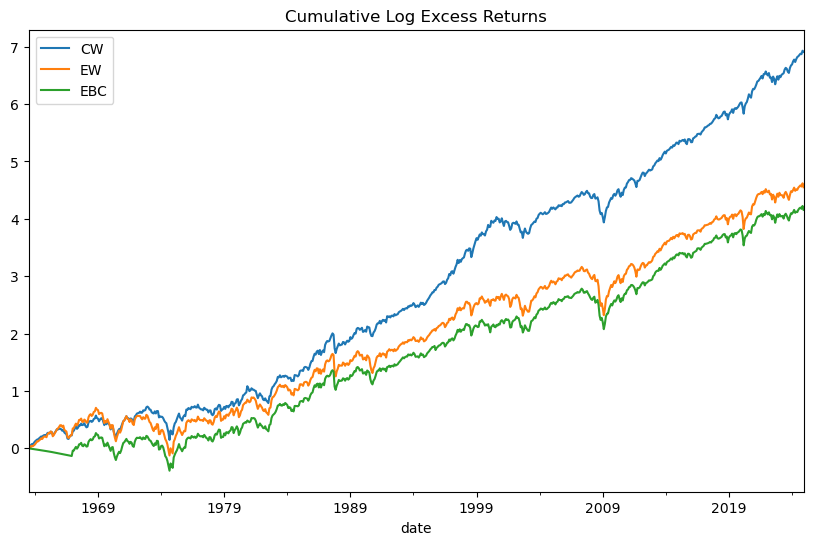

In [6]:
np.log1p(merged_df[['CW', 'EW', 'EBC']]).cumsum().plot(figsize=(10,6))
plt.title("Cumulative Log Excess Returns")
plt.show()

# <span style="color:red"> Get rolling betas for the two focus portfolios EBC and CW - EBC </span>

#### create factor returns

In [7]:
ebc = ebc.to_frame(name="EBC")
cw_ebc = cw_ebc.to_frame(name="CW-EBC")
factor_returns = pd.concat([ebc, cw_ebc], axis=1).dropna()
factor_returns.columns = ["EBC", "CW-EBC"]

#### get asset returns and make them excess

In [8]:
asset_returns = bd.build_returns_dataset("sp500_returns_monthly_with_tickers.csv", frequency="monthly")
ff_factors = bd.build_ff_dataset("ff_factors_monthly.csv", frequency="monthly")

asset_returns, ff_factors = asset_returns.align(ff_factors, join="inner", axis=0)
# Create the Excess Returns for the Assets
asset_excess_returns = asset_returns.sub(ff_factors["RF"], axis=0)

#### compute rolling betas for EBc and CW-EBC

In [9]:
asset_excess_returns, factor_returns = asset_excess_returns.align(factor_returns, join="inner", axis=0)

betas_ebc = fmb_betas.compute_rolling_betas(asset_excess_returns, ebc, rolling_window=36, min_obs=10)
betas_cw_ebc = fmb_betas.compute_rolling_betas(asset_excess_returns, cw_ebc, rolling_window=36, min_obs=10)

Estimating rolling betas: 100%|██████████| 702/702 [00:31<00:00, 22.52it/s]
/Users/evi/Desktop/Invesco_Research_Project/src/FamaMacBeth/betas.py:72: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  stacked = betas_df.stack(dropna=True)
Estimating rolling betas: 100%|██████████| 702/702 [00:30<00:00, 22.65it/s]
/Users/evi/Desktop/Invesco_Research_Project/src/FamaMacBeth/betas.py:72: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  stacked = betas_df.stack(dropna=True)


# <span style="color:red"> Run full factor pipeline --> Two factor regressions FMB </span>

In [10]:
start_date = "1999-10-01"

## Filter all returns to match start date

In [11]:
asset_excess_returns_trimmed = asset_excess_returns.loc[start_date:]
factor_returns_trimmed = factor_returns.loc[start_date:]
betas_ebc_trimmed = betas_ebc.loc[start_date:]
betas_cw_ebc_trimmed = betas_cw_ebc.loc[start_date:]

In [12]:
results = fmb_pipe.run_full_factor_pipeline(
    beta1_df=betas_ebc_trimmed,
    beta2_df=betas_cw_ebc_trimmed,
    sp500=asset_excess_returns_trimmed,
    EBC=factor_returns_trimmed["EBC"],
    Cap_EBC=factor_returns_trimmed["CW-EBC"],
    n_q1=3,
    n_q2=3,
    min_assets_per_cell=3,
    f1_name="EBC",
    f2_name="CW-EBC",
    frequency = 'monthly',
    formation_frequency='quarterly'
)

results["mean_grid"]

forming portfolios (quarterly): 100%|██████████| 101/101 [00:05<00:00, 18.49it/s]


,1,2,3
1,0.009741,0.008566,0.009850
2,0.008351,0.008867,0.009163
3,0.004497,0.006629,0.007687


# <span style="color:red"> Backtest </span>

In [13]:
# ============================
# USER PARAMETERS
# ============================
#start_date = "1970-01-01"


# ============================
# REQUIRED INPUTS FROM PIPELINE
# ============================
members_df = results["members"]
n_q1, n_q2 = results["mean_grid"].shape

# ============================
# LOAD RETURNS / CAPS / RF
# ============================
DATA_RAW_DIR = Path.cwd().parent / "data" / "raw"
sp_500, sp_caps, rf = fmb_backtest.load_monthly_inputs(DATA_RAW_DIR) ### excess sp_500

In [14]:
# ============================
# RUN BACKTEST
# ============================
quantile_portfolios_returns = fmb_backtest.backtest_quantile_portfolios(
    members_df=members_df,
    returns_df=sp_500,
    caps_df=sp_caps,
    n_q1=n_q1,
    n_q2=n_q2,
    weight="cap",
    frequency = 'monthly'
)
quantile_portfolios_returns = quantile_portfolios_returns.dropna(how='all')

Q1 buckets:   0%|          | 0/3 [00:00<?, ?it/s]

In [15]:
rename_map = {
    "Q1_Q1": "EBC_High_Pref_High",
    "Q1_Q2": "EBC_High_Pref_Mid",
    "Q1_Q3": "EBC_High_Pref_Low",
    "Q2_Q1": "EBC_Mid_Pref_High",
    "Q2_Q2": "EBC_Mid_Pref_Mid",
    "Q2_Q3": "EBC_Mid_Pref_Low",
    "Q3_Q1": "EBC_Low_Pref_High",
    "Q3_Q2": "EBC_Low_Pref_Mid",
    "Q3_Q3": "EBC_Low_Pref_Low",
}

quantile_portfolios_returns = quantile_portfolios_returns.rename(columns=rename_map)


In [16]:
quantile_portfolios_returns

,EBC_High_Pref_High,EBC_High_Pref_Mid,EBC_High_Pref_Low,EBC_Mid_Pref_High,EBC_Mid_Pref_Mid,EBC_Mid_Pref_Low,EBC_Low_Pref_High,EBC_Low_Pref_Mid,EBC_Low_Pref_Low
date,,,,,,,,,
2000-01-01,-0.060882,-0.084422,-0.070668,-0.007667,-0.000087,-0.080282,-0.035090,-0.039949,-0.007951
2000-02-01,0.083918,0.005399,-0.073079,0.100845,-0.099569,-0.087141,-0.056235,-0.127362,-0.097953
2000-03-01,0.095606,0.076770,0.086004,0.105121,0.154349,0.102419,0.114992,0.167264,0.081924
2000-04-01,-0.011310,-0.016781,0.049672,-0.051951,-0.012099,-0.022426,-0.015744,0.034959,0.041043
2000-05-01,-0.007364,0.039802,0.022392,-0.012645,0.035675,0.017522,-0.079727,0.062151,0.037932
...,...,...,...,...,...,...,...,...,...
2024-08-01,-0.000159,0.019492,0.014587,0.009471,0.030693,0.005328,0.032748,0.041336,0.040292
2024-09-01,0.047193,0.021768,0.037773,0.022257,0.012605,0.007633,0.005923,0.009750,-0.000691
2024-10-01,0.019870,-0.009846,-0.012709,-0.020197,0.009986,-0.005893,-0.022657,-0.028658,-0.003944


# <span style="color:red"> PLOTS </span>

In [17]:
full_merged_df.index = full_merged_df.index.to_timestamp(how="start")
full_merged_df.index.name = "date"


In [18]:
complete_df = full_merged_df.join(
    quantile_portfolios_returns,
    how="inner"
)


In [19]:
selected_columns = ['CW','EBC_High_Pref_High', 'EBC_High_Pref_Mid',
       'EBC_High_Pref_Low', 'EBC_Mid_Pref_High', 'EBC_Mid_Pref_Mid',
       'EBC_Mid_Pref_Low', 'EBC_Low_Pref_High', 'EBC_Low_Pref_Mid',
       'EBC_Low_Pref_Low']

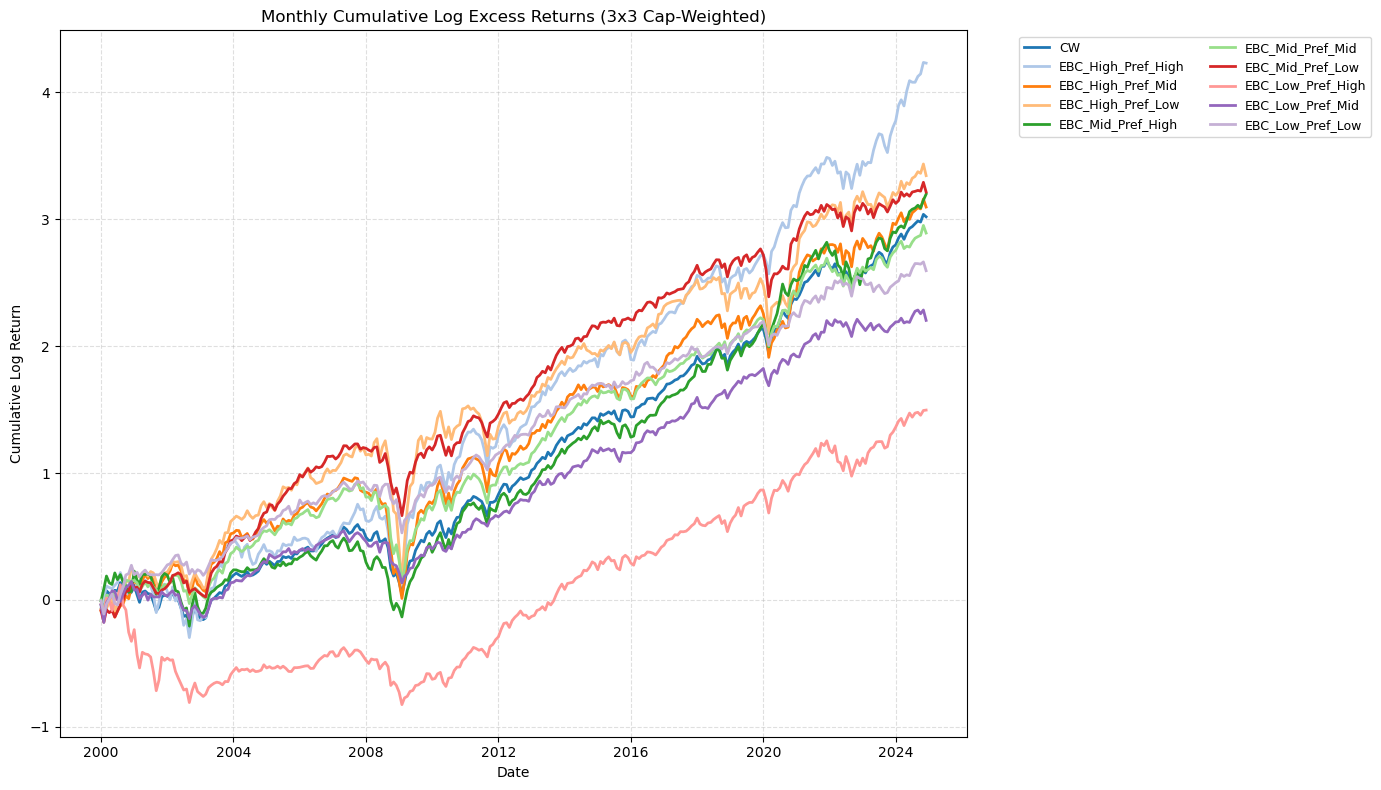

In [20]:
# ============================
# PLOTS
# ============================
fmb_plots.plot_cum_log_returns(
    complete_df[selected_columns],
    title=f"Monthly Cumulative Log Excess Returns ({n_q1}x{n_q2} Cap-Weighted)",
)

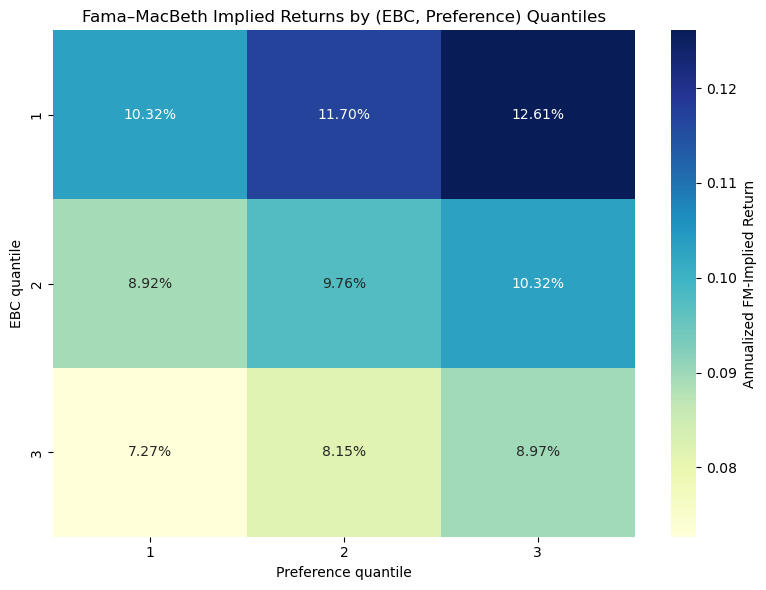

In [21]:
# FM expected-return grid (annualized %)
implied_returns = fmb_plots.plot_expected_return_grid(results["pricing"], results["fm_table"], n_q1, n_q2)

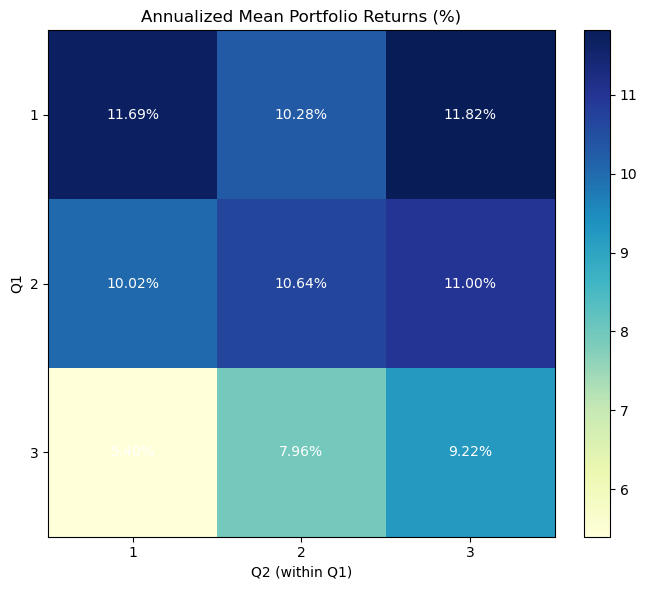

In [22]:
actual_returns = fmb_plots.plot_mean_grid(results["mean_grid"], annualize=True)

# <span style="color:red"> Save Files </span>

In [23]:

DATA_PROCESSED_DIR_KEN = PROJECT_ROOT / "data" / "processed" / "Ken"

period = start_date[:4] + '_2024'
period

'1999_2024'

## Save implied monthly returns

In [24]:
implied_returns_renamed = implied_returns
implied_returns_renamed = implied_returns_renamed.rename(
    index={
        1: "High EBC",
        2: "Medium EBC",
        3: "Low EBC"
    },
    columns={
        1: "High Preference",
        2: "Medium Preference",
        3: "Low Preference"
    }
)
implied_returns_renamed.to_csv(DATA_PROCESSED_DIR_KEN/ f"monthly_{period}_implied_returns.csv")


## Save actual monthly returns

In [25]:
actual_returns_renamed = actual_returns

actual_returns_renamed = actual_returns_renamed.rename(
    index={
        1: "High EBC",
        2: "Medium EBC",
        3: "Low EBC"
    },
    columns={
        1: "High Preference",
        2: "Medium Preference",
        3: "Low Preference"
    }
)

actual_excel = actual_returns_renamed / 100

actual_excel.to_csv(DATA_PROCESSED_DIR_KEN/ f"monthly_{period}_actual_returns.csv")


## Save actual quantile time series

In [26]:
quantile_portfolios_returns_copy = quantile_portfolios_returns.copy()

quantile_portfolios_returns_copy.index = (
    quantile_portfolios_returns_copy.index.to_period("M")
)
quantile_portfolios_returns_copy.index.name = "date"

save_dir = DATA_PROCESSED_DIR / 'monthly'

quantile_portfolios_returns_copy.to_csv(save_dir / f"monthly_{period}_quantile_returns_3x3.csv")

# <span style="color:red"> Fitted GARCH </span>

In [27]:
from arch import arch_model


In [28]:
def fit_garch_model(returns):
    """
    Fit GARCH(1,1) with student t errors
    """

    returns = returns.dropna()

    # Scale to percentage
    returns_scaled = returns * 100

    am = arch_model(
        returns_scaled,
        mean="Constant",
        vol="GARCH",
        p=1,
        q=1,
        dist="t"
    )

    res = am.fit(disp="off")

    return res


In [29]:
complete_df.columns

Index(['CW', 'EW', 'EBC', 'MKT_RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF', 'MOM',
       'CW-EW', 'CW-EBC', 'EBC_High_Pref_High', 'EBC_High_Pref_Mid',
       'EBC_High_Pref_Low', 'EBC_Mid_Pref_High', 'EBC_Mid_Pref_Mid',
       'EBC_Mid_Pref_Low', 'EBC_Low_Pref_High', 'EBC_Low_Pref_Mid',
       'EBC_Low_Pref_Low'],
      dtype='object')

In [30]:
portfolio_name = 'CW'

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                           CW   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -841.612
Distribution:      Standardized Student's t   AIC:                           1693.22
Method:                  Maximum Likelihood   BIC:                           1711.74
                                              No. Observations:                  300
Date:                      Thu, Feb 26 2026   Df Residuals:                      299
Time:                              20:44:52   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             1

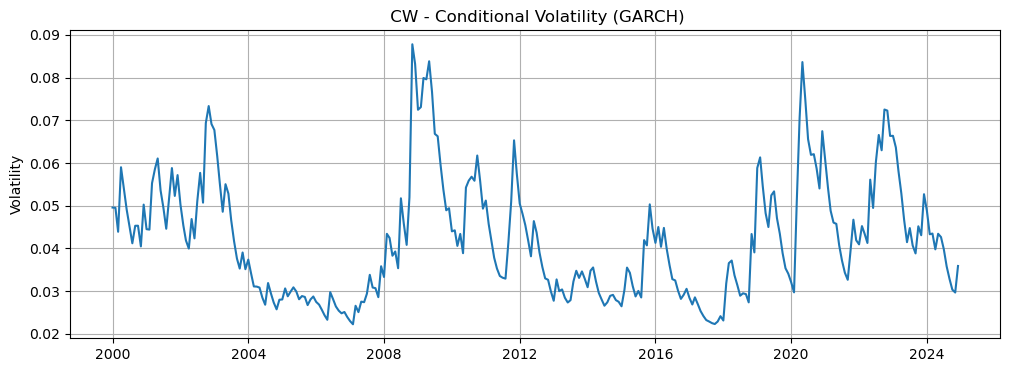

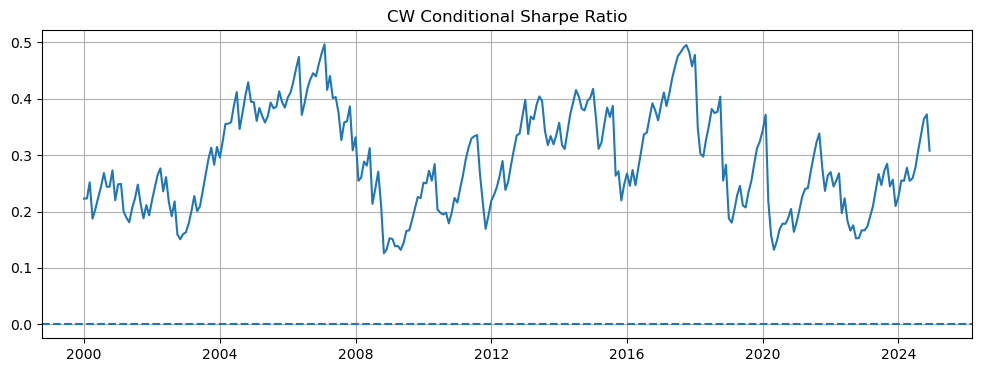

In [31]:
portfolio = complete_df[portfolio_name]

garch_res = fit_garch_model(portfolio)

print(garch_res.summary())


cond_vol = garch_res.conditional_volatility / 100  # scale back

plt.figure(figsize=(12,4))
plt.plot(cond_vol)
plt.title(f" {portfolio_name} - Conditional Volatility (GARCH)")
plt.ylabel("Volatility")
plt.grid(True)
plt.show()

mean_return = portfolio.mean()

cond_sharpe = mean_return / cond_vol

plt.figure(figsize=(12,4))
plt.plot(cond_sharpe)
plt.axhline(0, linestyle="--")
plt.title(f"{portfolio_name} Conditional Sharpe Ratio")
plt.grid(True)
plt.show()



